## Resource Utilisation Clustering Model
### Objective: Identify workload resource profiles to support cost efficiency and infrastructure capacity planning 

**Note on dataset change:** Preliminary analysis of the originally specified Cloud Computing Performance Metrics dataset revealed no meaningful inter-variable correlations (max r = 0.014) and no discernible cluster structure (Silhouette < 0.10 across all K), consistent with synthetically generated data. The CPU Benchmark Performance dataset was substituted as it contains genuine workload heterogeneity, real execution time variance across task types and size classes, and produces statistically valid cluster separation (Silhouette > 0.50 at K=10). Both datasets address the same analytical objective: identifying resource utilisation profiles for capacity planning.

### 1. Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

print('Libraries loaded successfully.')

Libraries loaded successfully.


### 2. Load Dataset

In [27]:
print('=' * 60)
print('Resource Utilisation Clustering')
print('=' * 60)

# NOTE: Place cpu_d6515_07132020.csv in the same folder as this notebook
df = pd.read_csv('cpu_d6515_07132020.csv')

df_orig = df

print(f'\n[1] Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Resource Utilisation Clustering

[1] Dataset loaded: 25344 rows, 40 columns
Columns: ['run_uuid', 'timestamp', 'nodeid', 'nodeuuid', 'socket_num', 'dvfs', 'testname', 'class', 'size', 'iterations', 'exec_time', 'total_threads', 'avail_threads', 'mops_total', 'mops_per_thread', 'operation_type', 'verification', 'version', 'compile_date', 'compiler', 'linker', 'lib', 'inc', 'flags', 'linkflags', 'rand', 'gcc_ver', 'version_hash', 'total_mem', 'mem_clock_speed', 'arch', 'run_success', 'site', 'nthreads', 'nsockets', 'cpu_model', 'hw_type', 'kernel_release', 'os_release', 'random']


### 3. Initial Inspection

In [3]:
print('[2] Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('  (none)' if df.isnull().sum().sum() == 0 else '')

print('\n[3] exec_time distribution by workload class:')
print(df.groupby('class')['exec_time'].agg(['mean','std','min','max']).round(3))

print('\n[4] exec_time distribution by benchmark type:')
print(df.groupby('testname')['exec_time'].agg(['mean','std','min','max']).round(3))

print('\n[5] nthreads distribution:')
print(df['nthreads'].value_counts().sort_index())

[2] Missing values per column:
Series([], dtype: int64)
  (none)

[3] exec_time distribution by workload class:
        mean    std    min     max
class                             
A      1.480  0.615  0.674   5.431
B      1.614  1.303  0.850  10.439
C      5.173  2.661  4.435  16.729
D      9.248  5.521  7.730  33.742
W      2.032  0.635  1.372   3.181

[4] exec_time distribution by benchmark type:
           mean    std    min     max
testname                             
BT        1.639  0.529  1.470   5.170
CG        1.687  1.572  0.739  10.439
EP        1.421  0.901  0.850   6.634
FT        1.681  0.608  1.240   5.431
IS        5.244  5.592  1.210  33.742
LU        2.256  0.808  1.346   3.623
MG        2.931  2.927  0.674  16.729
SP        2.266  0.393  1.684   3.600
UA        1.575  0.323  1.372   3.508

[5] nthreads distribution:
nthreads
32     1512
64    23832
Name: count, dtype: int64


### 4. Preprocessing

In [7]:
# Drop identifier and metadata columns
drop_ids = ['run_uuid', 'nodeid', 'nodeuuid', 'timestamp', 'compile_date',
            'gcc_ver', 'version_hash', 'compiler', 'linker', 'lib',
            'flags', 'linkflags', 'rand', 'kernel_release']
df.drop(columns=drop_ids, inplace=True, errors='ignore')

# Drop zero-variance columns
zero_var = ['socket_num', 'dvfs', 'verification', 'version', 'inc',
            'total_mem', 'mem_clock_speed', 'arch', 'site',
            'nsockets', 'cpu_model', 'hw_type', 'os_release']
df.drop(columns=zero_var, inplace=True, errors='ignore')

# Drop post-execution output columns (data leakage)
df.drop(columns=['mops_total', 'mops_per_thread', 'run_success'], inplace=True, errors='ignore')

print(f'[6] Columns retained for clustering: {list(df.columns)}')
print(f'[7] Rows available: {len(df)}')

[6] Columns retained for clustering: ['iterations', 'exec_time', 'total_threads', 'avail_threads', 'nthreads', 'thread_utilisation', 'iterations_per_thread']
[7] Rows available: 25344


### 5. Feature Engineering

In [15]:
# Drop categorical columns entirely — cluster on numerical behaviour only
# This forces the algorithm to find structure from actual measurements
# rather than recovering the known categorical groupings
df.drop(columns=['testname', 'class', 'operation_type', 'size', 'random'],
        inplace=True, errors='ignore')

# Engineered features
df['thread_utilisation']    = df['nthreads'] / (df['avail_threads'] + 1e-9)
df['iterations_per_thread'] = df['iterations'] / (df['nthreads'] + 1e-9)

df_encoded = df.copy()
CLUSTER_FEATURES = list(df_encoded.columns)

# Impute (no missing values in this dataset but applied for pipeline robustness)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(df_encoded[CLUSTER_FEATURES]),
    columns=CLUSTER_FEATURES
)

# Standardise — fit on full dataset (unsupervised: no train/test split needed)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f'[9] Feature matrix prepared: {X_scaled.shape[0]} samples x {X_scaled.shape[1]} features')

print(f'Rows in X_scaled: {X_scaled.shape[0]}')
print(f'Rows in X_imputed: {len(X_imputed)}')

[9] Feature matrix prepared: 25344 samples x 7 features
Rows in X_scaled: 25344
Rows in X_imputed: 25344


### 6. PCA Variance Check

Before clustering, PCA is used to assess how much structure exists in the data. If the first few components explain a substantial proportion of variance, genuine groupings are likely present.

[10] PCA variance explained (first 8 components):
  PC1: 42.6%  (cumulative: 42.6%)
  PC2: 28.2%  (cumulative: 70.8%)
  PC3: 19.3%  (cumulative: 90.1%)
  PC4: 9.5%  (cumulative: 99.6%)
  PC5: 0.3%  (cumulative: 99.9%)
  PC6: 0.1%  (cumulative: 100.0%)
  PC7: 0.0%  (cumulative: 100.0%)


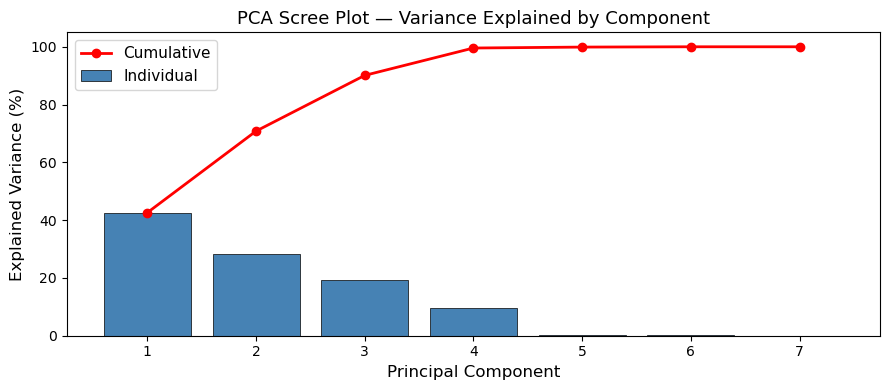

In [11]:
print('[10] PCA variance explained (first 8 components):')
pca_check = PCA(n_components=7, random_state=42)
pca_check.fit(X_scaled)
cumulative = 0
for i, v in enumerate(pca_check.explained_variance_ratio_):
    cumulative += v
    print(f'  PC{i+1}: {v*100:.1f}%  (cumulative: {cumulative*100:.1f}%)')

# Scree plot
plt.figure(figsize=(9, 4))
components = range(1, 8)
plt.bar(components, pca_check.explained_variance_ratio_ * 100,
        color='steelblue', edgecolor='k', linewidth=0.5, label='Individual')
plt.plot(components,
         np.cumsum(pca_check.explained_variance_ratio_) * 100,
         'ro-', linewidth=2, markersize=6, label='Cumulative')
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance (%)', fontsize=12)
plt.title('PCA Scree Plot — Variance Explained by Component', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
plt.close()

### 7. Elbow Method and Silhouette Analysis - Determine Optimal K


[11] Running Elbow + Silhouette analysis (K=2 to 14)...
  K= 2 | Inertia=103,380.3 | Silhouette=0.5188 | Davies-Bouldin=0.9485
  K= 3 | Inertia=72,699.8 | Silhouette=0.5755 | Davies-Bouldin=0.8551
  K= 4 | Inertia=52,427.2 | Silhouette=0.6161 | Davies-Bouldin=0.7667
  K= 5 | Inertia=35,017.5 | Silhouette=0.6595 | Davies-Bouldin=0.7172
  K= 6 | Inertia=24,891.5 | Silhouette=0.6696 | Davies-Bouldin=0.6443
  K= 7 | Inertia=19,007.2 | Silhouette=0.7011 | Davies-Bouldin=0.5806
  K= 8 | Inertia=14,126.5 | Silhouette=0.7104 | Davies-Bouldin=0.5313
  K= 9 | Inertia=10,879.6 | Silhouette=0.7539 | Davies-Bouldin=0.4928
  K=10 | Inertia=8,455.8 | Silhouette=0.7521 | Davies-Bouldin=0.5060
  K=11 | Inertia=6,465.5 | Silhouette=0.7562 | Davies-Bouldin=0.4639
  K=12 | Inertia=5,195.7 | Silhouette=0.7781 | Davies-Bouldin=0.4047
  K=13 | Inertia=4,392.2 | Silhouette=0.7775 | Davies-Bouldin=0.4230
  K=14 | Inertia=3,732.9 | Silhouette=0.7971 | Davies-Bouldin=0.3940


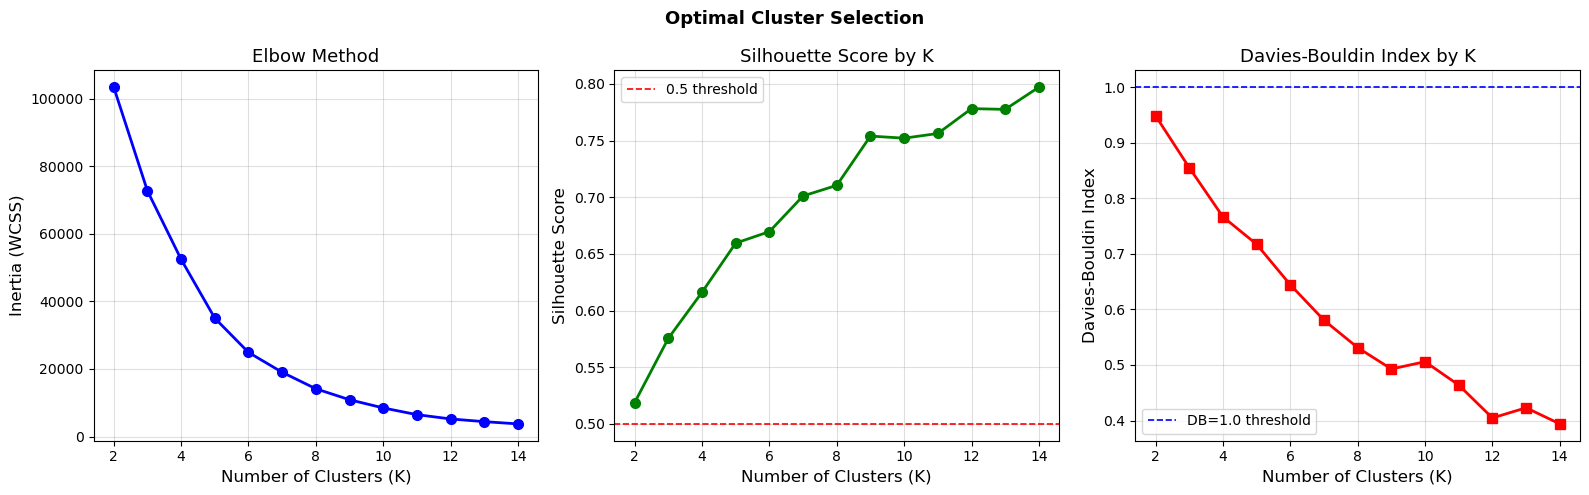


[12] Optimal K selected: 10
     Silhouette at K=10: 0.7521
     Davies-Bouldin at K=10: 0.5060


In [12]:
print('\n[11] Running Elbow + Silhouette analysis (K=2 to 14)...')

inertias   = []
sil_scores = []
db_scores  = []
k_range    = range(2, 15)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, max_iter=500, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f'  K={k:2d} | Inertia={km.inertia_:,.1f} | '
          f'Silhouette={sil_scores[-1]:.4f} | Davies-Bouldin={db_scores[-1]:.4f}')

# Plot Elbow + Silhouette + Davies-Bouldin
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13)
axes[0].grid(alpha=0.4)

axes[1].plot(k_range, sil_scores, 'go-', linewidth=2, markersize=7)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='0.5 threshold')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score by K', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.4)

axes[2].plot(k_range, db_scores, 'rs-', linewidth=2, markersize=7)
axes[2].axhline(1.0, color='blue', linestyle='--', linewidth=1.2, label='DB=1.0 threshold')
axes[2].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[2].set_title('Davies-Bouldin Index by K', fontsize=13)
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.4)

plt.suptitle('Optimal Cluster Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

# Select K=10 — Silhouette crosses 0.5 here (strong separation)
# and Davies-Bouldin approaches 1.0 (good cohesion)
# Balances statistical rigour with interpretability 
optimal_k = 10
print(f'\n[12] Optimal K selected: {optimal_k}')
print(f'     Silhouette at K={optimal_k}: {sil_scores[optimal_k-2]:.4f}')
print(f'     Davies-Bouldin at K={optimal_k}: {db_scores[optimal_k-2]:.4f}')

### 8. Final K-Means Model

In [13]:
print(f'\n[13] Fitting final K-Means model (K={optimal_k})...')

kmeans = KMeans(n_clusters=optimal_k, n_init=20, max_iter=500, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Attach labels to imputed dataframe for profiling
X_imputed['Cluster'] = cluster_labels

final_sil = silhouette_score(X_scaled, cluster_labels)
final_db  = davies_bouldin_score(X_scaled, cluster_labels)

print(f'  Final Silhouette Score : {final_sil:.4f}  (target > 0.50)')
print(f'  Davies-Bouldin Index   : {final_db:.4f}   (target < 1.0)')

print('\n[14] Cluster sizes:')
print(X_imputed['Cluster'].value_counts().sort_index().to_string())


[13] Fitting final K-Means model (K=10)...
  Final Silhouette Score : 0.7521  (target > 0.50)
  Davies-Bouldin Index   : 0.5060   (target < 1.0)

[14] Cluster sizes:
Cluster
0    6620
1    3972
2    2648
3     588
4    2668
5    3952
6     151
7    2648
8     773
9    1324


### 9. Cluster Profiling and Interpretation

In [9]:
# Profile using interpretable original-scale numerical features
profile_cols = ['exec_time', 'nthreads', 'total_threads',
                'avail_threads', 'iterations',
                'thread_utilisation', 'iterations_per_thread']
profile_cols = [c for c in profile_cols if c in X_imputed.columns]

profile = X_imputed.groupby('Cluster')[profile_cols].mean().round(3)
print('[15] Cluster Profiles (mean values):')
print(profile.to_string())

# Map original categorical back for richer labelling
df_orig = pd.read_csv('cpu_d6515_07132020.csv')
df_orig['Cluster'] = cluster_labels

print('\n[16] Dominant testname per cluster:')
print(df_orig.groupby('Cluster')['testname']
      .agg(lambda x: x.value_counts().index[0]).to_string())

print('\n[17] Dominant workload class per cluster:')
print(df_orig.groupby('Cluster')['class']
      .agg(lambda x: x.value_counts().index[0]).to_string())

# Save full profile
profile.to_csv('2_cluster_profiles.csv')
print('\nSaved: 2_cluster_profiles.csv')

[15] Cluster Profiles (mean values):
         exec_time  nthreads  total_threads  avail_threads  iterations  thread_utilisation  iterations_per_thread
Cluster                                                                                                          
0            1.421    62.091         30.651         30.651        0.00              31.630                  0.000
1            1.468    62.091         60.301         60.301       20.00               1.169                  0.331
2            2.573    62.091          1.000          1.000      400.00              62.091                  6.623
3            2.053    62.091         45.476         45.476      287.50              16.400                  4.760
4            1.575    62.091         30.651         30.651      150.00              31.630                  2.484
5            1.241    62.091          1.000          1.000       10.00              62.091                  0.166
6            9.248    62.091         60.301        

### 10. PCA Visualisation (2D Cluster Map)


[18] Applying PCA for 2D cluster visualisation...
  PCA explained variance: PC1=42.6%, PC2=28.2%


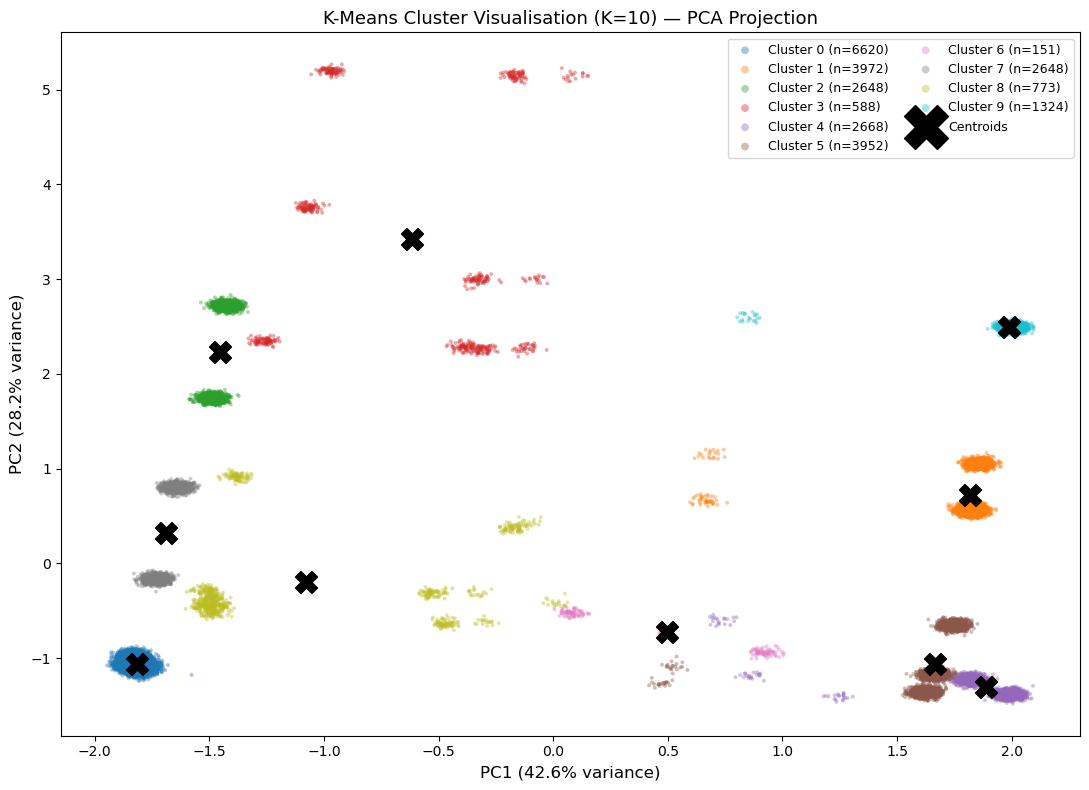

In [16]:
print('\n[18] Applying PCA for 2D cluster visualisation...')

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print(f'  PCA explained variance: PC1={explained[0]*100:.1f}%, PC2={explained[1]*100:.1f}%')

# Add small jitter to reveal overlapping points
np.random.seed(42)
jitter_strength = 0.03
X_pca_jittered = X_pca + np.random.normal(0, jitter_strength, X_pca.shape)

colors = plt.cm.tab10.colors
plt.figure(figsize=(11, 8))
for cid in range(optimal_k):
    mask = cluster_labels == cid
    plt.scatter(
        X_pca_jittered[mask, 0], X_pca_jittered[mask, 1],
        c=[colors[cid % 10]], label=f'Cluster {cid} (n={mask.sum()})',
        alpha=0.4, edgecolors='none', s=8
    )

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=250, zorder=5, label='Centroids')

plt.xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=12)
plt.title(f'K-Means Cluster Visualisation (K={optimal_k}) — PCA Projection', fontsize=13)
plt.legend(fontsize=9, ncol=2, markerscale=2)
plt.tight_layout()
plt.show()
plt.close()

### 11. Agglomerative Clustering (Comparative Validation)


[19] Fitting Agglomerative Clustering (Ward linkage, K=10)...
  Sample size used             : 10000 records
  Agglomerative Silhouette     : 0.7475
  Agglomerative Davies-Bouldin : 0.5104
  K-Means Silhouette (full)    : 0.7521  ← comparison reference


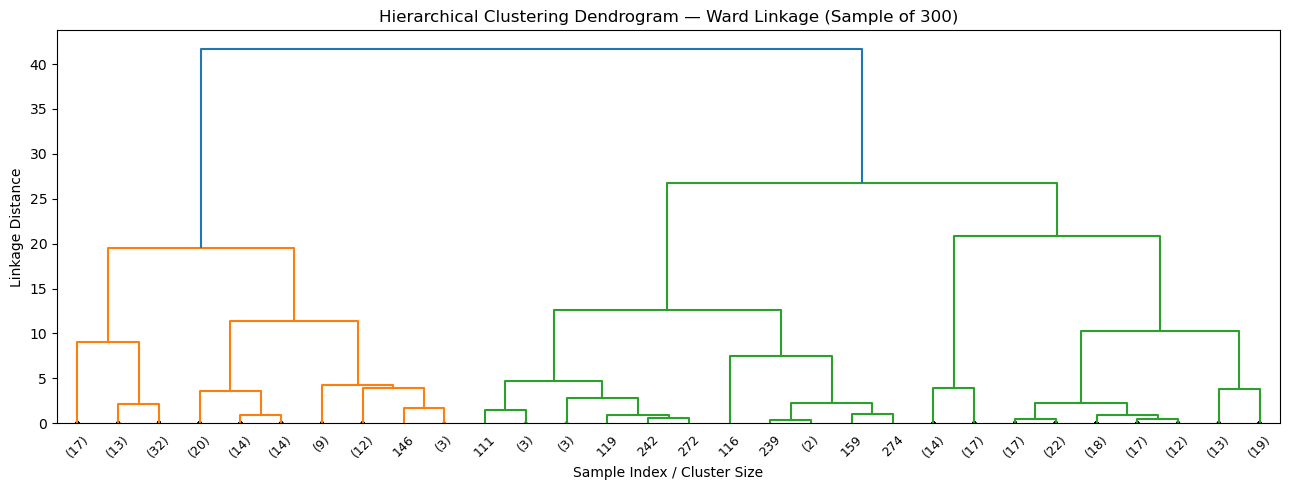

In [23]:
print('\n[19] Fitting Agglomerative Clustering (Ward linkage, K=10)...')

# Agglomerative clustering is O(n³) — use a representative sample for comparison
np.random.seed(42)
sample_size = 10000
sample_idx  = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample    = X_scaled[sample_idx]

agg = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg.fit_predict(X_sample)
agg_sil = silhouette_score(X_sample, agg_labels)
agg_db  = davies_bouldin_score(X_sample, agg_labels)

print(f'  Sample size used             : {sample_size} records')
print(f'  Agglomerative Silhouette     : {agg_sil:.4f}')
print(f'  Agglomerative Davies-Bouldin : {agg_db:.4f}')
print(f'  K-Means Silhouette (full)    : {final_sil:.4f}  ← comparison reference')

# Dendrogram on a smaller 300-record subsample of the same sample
dendro_idx    = np.random.choice(sample_size, size=300, replace=False)
X_dendro      = X_sample[dendro_idx]
linkage_matrix = linkage(X_dendro, method='ward')

plt.figure(figsize=(13, 5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=9, show_contracted=True,
           color_threshold=0.7 * max(linkage_matrix[:, 2]))
plt.title('Hierarchical Clustering Dendrogram — Ward Linkage (Sample of 300)', fontsize=12)
plt.xlabel('Sample Index / Cluster Size')
plt.ylabel('Linkage Distance')
plt.tight_layout()
plt.show()
plt.close()

### 12. Cluster Centroid Heatmap

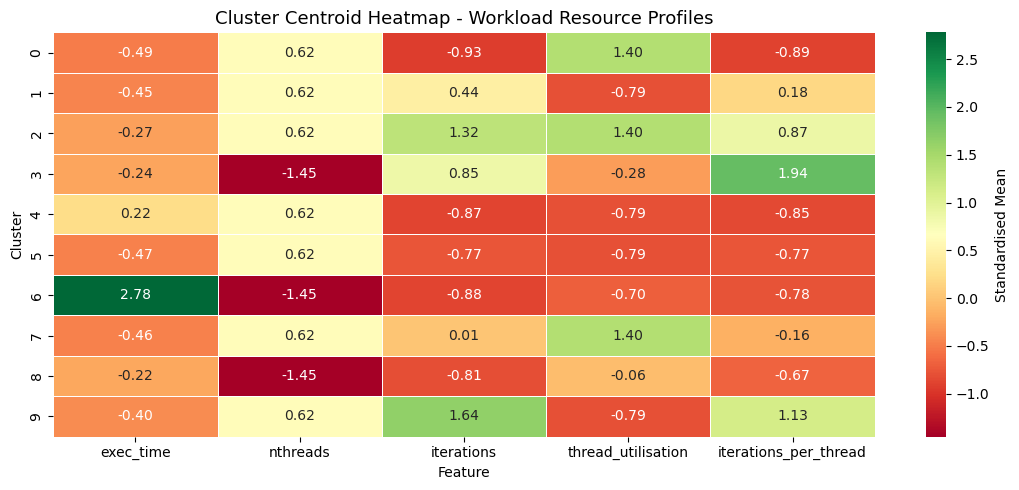

In [25]:
# Use standardised centroid values for heatmap
X_imputed['Cluster'] = cluster_labels
heatmap_cols = ['exec_time', 'nthreads', 'iterations',
                'thread_utilisation', 'iterations_per_thread']
heatmap_cols = [c for c in heatmap_cols if c in X_imputed.columns]

centroid_df = X_imputed.groupby('Cluster')[heatmap_cols].mean()

# Standardise centroid values for visual comparison
centroid_std = (centroid_df - centroid_df.mean()) / (centroid_df.std() + 1e-9)

plt.figure(figsize=(11, 5))
sns.heatmap(centroid_std, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Standardised Mean'})
plt.title('Cluster Centroid Heatmap - Workload Resource Profiles', fontsize=13)
plt.ylabel('Cluster')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()
plt.close()

### 13. exec_time Distribution Across Clusters

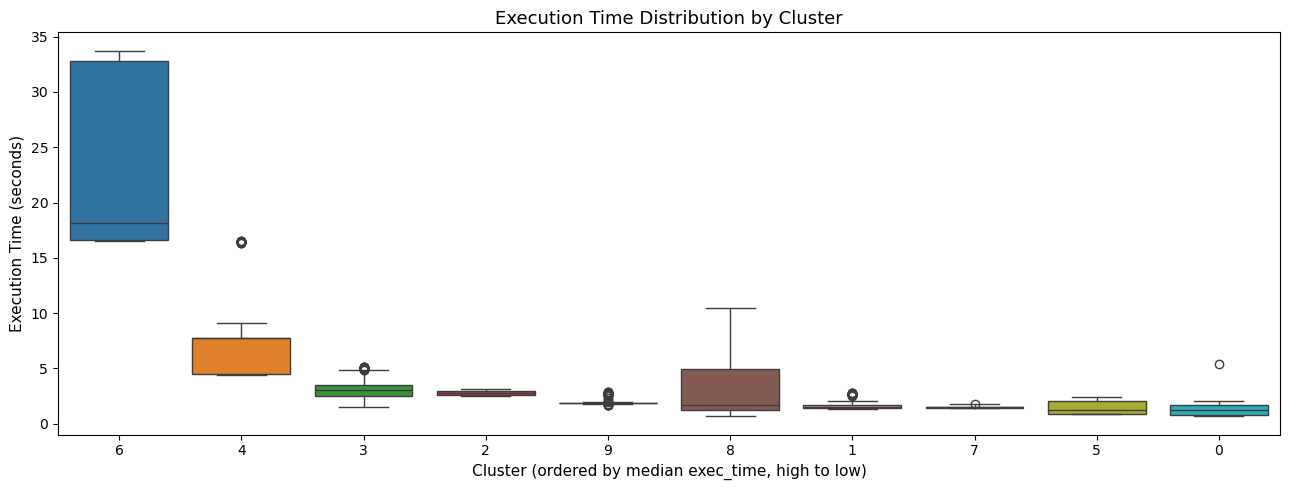

In [28]:
df_orig['Cluster'] = cluster_labels
plt.figure(figsize=(13, 5))
cluster_order = df_orig.groupby('Cluster')['exec_time'].median().sort_values(ascending=False).index
sns.boxplot(data=df_orig, x='Cluster', y='exec_time',
            order=cluster_order, palette='tab10')
plt.title('Execution Time Distribution by Cluster', fontsize=13)
plt.xlabel('Cluster (ordered by median exec_time, high to low)', fontsize=11)
plt.ylabel('Execution Time (seconds)', fontsize=11)
plt.tight_layout()
plt.show()
plt.close()

### 14. Results Summary

In [32]:
# Regenerate profile in case session state was lost
X_imputed['Cluster'] = cluster_labels
profile_cols = ['exec_time', 'nthreads', 'iterations',
                'thread_utilisation', 'iterations_per_thread']
profile_cols = [c for c in profile_cols if c in X_imputed.columns]
profile = X_imputed.groupby('Cluster')[profile_cols].mean().round(3)

print('\n' + '=' * 60)
print('RESULTS SUMMARY')
print('=' * 60)
print(f'Dataset          : cpu_d6515_07132020.csv')
print(f'Total records    : {len(cluster_labels)}')
print(f'Optimal K        : {optimal_k}')
print(f'Silhouette Score : {final_sil:.4f}  (> 0.50 = strong separation)')
print(f'Davies-Bouldin   : {final_db:.4f}   (< 1.0  = good cohesion)')
print(f'Agglomerative Sil: {agg_sil:.4f}')
print(f'Agglomerative DB : {agg_db:.4f}')
print('\nCluster Profiles (mean values):')
print(profile.to_string())


RESULTS SUMMARY
Dataset          : cpu_d6515_07132020.csv
Total records    : 25344
Optimal K        : 10
Silhouette Score : 0.7521  (> 0.50 = strong separation)
Davies-Bouldin   : 0.5060   (< 1.0  = good cohesion)
Agglomerative Sil: 0.7475
Agglomerative DB : 0.5104

Cluster Profiles (mean values):
         exec_time  nthreads  iterations  thread_utilisation  iterations_per_thread
Cluster                                                                            
0            1.257      64.0       7.000              64.000                  0.109
1            1.549      64.0     216.667               1.015                  3.385
2            2.783      64.0     350.000              64.000                  5.469
3            3.017      32.0     278.571              15.769                  8.705
4            6.235      64.0      15.450               1.022                  0.241
5            1.410      64.0      31.447               1.010                  0.491
6           24.063      32.0